task1

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

%matplotlib inline

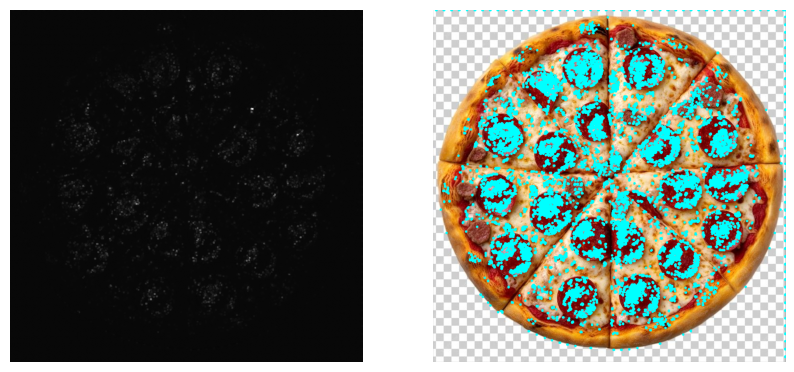

In [13]:
image = cv2.imread('./img1.jpg')
image_Copy = np.copy(image)
image_copy = cv2.cvtColor(image_Copy, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image_copy, cv2.COLOR_RGB2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)
dst = cv2.dilate(dst,None)

threshold = 0.01*dst.max()
corner_image = np.copy(image_copy)
for j in range(0, dst.shape[0]):
    for i in range(0, dst.shape[1]):
        if(dst[j,i] > threshold):
            cv2.circle( corner_image, (i, j), 1, (0,255,255), 1)

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(dst, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(corner_image)
plt.axis('off')

plt.show()

Yes it can detect pepperoni slices but not accurate and yes the crust edges are identified as corners. In terms of "cheese texture", the algorithm can't detect that. Only where it's bumpy in cheese texture, that part is detected.

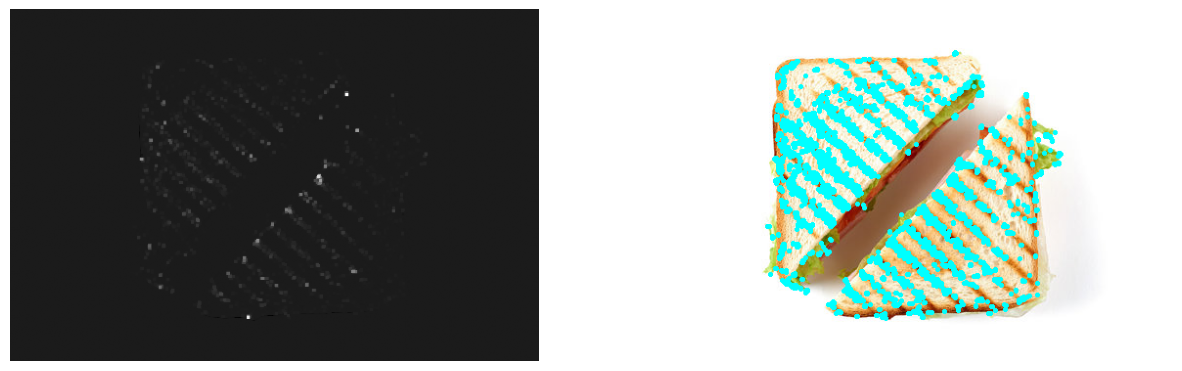

In [21]:
image = cv2.imread('./sandwich1.jpg')
cake_image_Copy = np.copy(image)
cake_image_copy = cv2.cvtColor(cake_image_Copy, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(cake_image_copy, cv2.COLOR_RGB2GRAY)
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, 2, 3, 0.04)
dst = cv2.dilate(dst,None)

threshold = 0.01*dst.max()
corner_image = np.copy(cake_image_copy)
for j in range(0, dst.shape[0]):
    for i in range(0, dst.shape[1]):
        if(dst[j,i] > threshold):
            cv2.circle( corner_image, (i, j), 1, (0,255,255), 1)

plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
plt.imshow(dst, cmap='gray')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(corner_image)
plt.axis('off')
plt.show()

as it has more sharp edges and corners, Haris corner detection can detect it more accurately. So the algorithm is happiest in this case.

task2

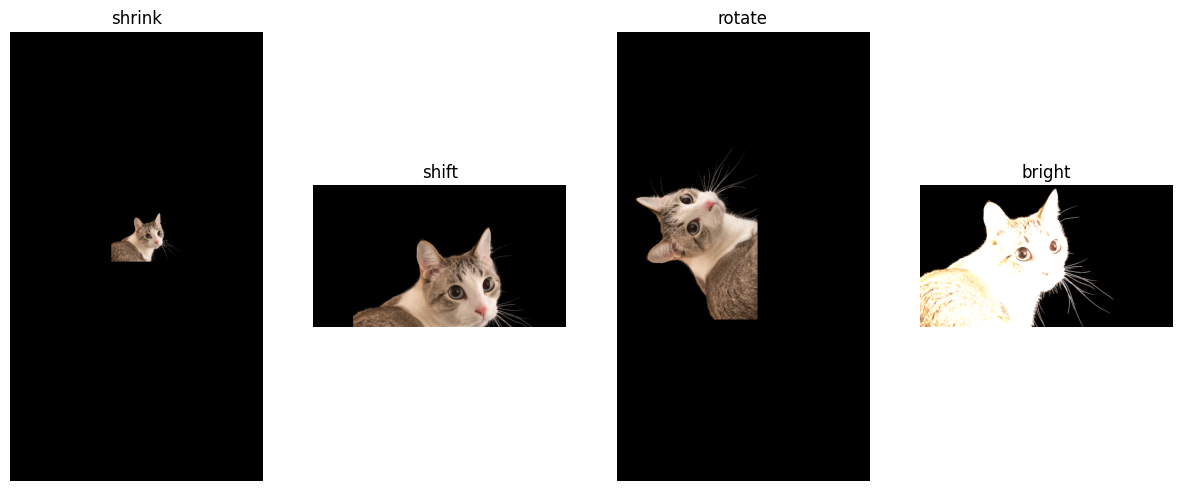

In [15]:
transformed_images = []
# shrink
image1 = cv2.imread('./c3.jpg')
num_rows, num_cols = image1.shape[:2]
M = cv2.getRotationMatrix2D((num_rows/2,num_cols/2),0,0.2)
dst = cv2.warpAffine(image1,M,(num_rows,num_cols))
dst = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
transformed_images.append(dst)

# shift
shift_x = 190
shift_y = 180
translation_matrix = np.float32([[1, 0, shift_x],
                                 [0, 1, shift_y]])
translated = cv2.warpAffine(image1, translation_matrix, (num_cols, num_rows))
translated_rgb = cv2.cvtColor(translated, cv2.COLOR_BGR2RGB)
transformed_images.append(translated_rgb)

# rotate
M = cv2.getRotationMatrix2D((num_rows/2,num_cols/2),90,0.5)
dst1 = cv2.warpAffine(image1,M,(num_rows,num_cols))
dst1 = cv2.cvtColor(dst1, cv2.COLOR_BGR2RGB)
transformed_images.append(dst1)

# bright
def brightness_augmentation(image, factor):
  adjusted_image = np.clip(image * factor, 0, 255).astype(np.uint8)
  return adjusted_image

bright_img = brightness_augmentation(image1, 3.5)
bright_img = cv2.cvtColor(bright_img, cv2.COLOR_BGR2RGB)
transformed_images.append(bright_img)

plt.figure(figsize=(15,10))
plt.subplot(1,4,1)
plt.imshow(dst)
plt.title('shrink')
plt.axis('off')
plt.subplot(1,4,2)
plt.imshow(translated_rgb)
plt.title('shift')
plt.axis('off')
plt.subplot(1,4,3)
plt.imshow(dst1)
plt.title('rotate')
plt.axis('off')
plt.subplot(1,4,4)
plt.imshow(bright_img)
plt.title('bright')
plt.axis('off')
plt.show()

In [16]:
image1 = cv2.imread('./c3.jpg')
sift = cv2.SIFT_create()
training_image = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
transformed_list = ['Shrinked image', 'Shifted image', 'Rotateed image', 'Brightened image']

for i in range(len(transformed_images)):
  test_image = cv2.pyrDown(training_image)
  test_image = cv2.pyrDown(transformed_images[i])

  training_gray = cv2.cvtColor(training_image, cv2.COLOR_RGB2GRAY)
  test_gray = cv2.cvtColor(test_image, cv2.COLOR_RGB2GRAY)
  train_keypoints, train_descriptor = sift.detectAndCompute(training_gray, None)
  test_keypoints, test_descriptor = sift.detectAndCompute(test_gray, None)
  keypoints_without_size = np.copy(training_image)
  keypoints_with_size = np.copy(training_image)

  cv2.drawKeypoints(training_image, train_keypoints, keypoints_without_size, color = (0, 255, 0))
  cv2.drawKeypoints(training_image, train_keypoints, keypoints_with_size, flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

  fig, axes = plt.subplots(1, 2, figsize=(20, 15))
  axes[0].imshow(keypoints_with_size)
  axes[0].set_title("Train Keypoints With Size")
  axes[0].axis('off')
  axes[1].set_title("Train Keypoints Without Size")
  axes[1].imshow(keypoints_without_size)
  axes[1].axis('off')
  plt.tight_layout()
  plt.show()

  print("Number of Keypoints Detected In The Training Image:", len(train_keypoints))
  print("Number of Keypoints Detected In The Query Image:", len(test_keypoints))
  print("Matching point for",transformed_list[i])

  bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck = False)
  matches = bf.match(train_descriptor, test_descriptor)
  matches = sorted(matches, key = lambda x : x.distance)
  result = cv2.drawMatches(training_image, train_keypoints, test_gray, test_keypoints, matches, test_gray, flags = 2)
  plt.rcParams['figure.figsize'] = [14.0, 7.0]
  plt.title('Matching Points')
  plt.imshow(result)
  plt.axis('off')
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

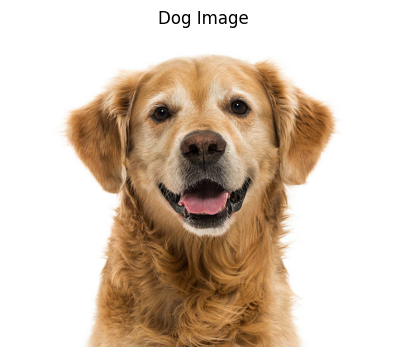

In [17]:
dog_img = cv2.imread("./doggo.jpg")
dog_img_rgb = cv2.cvtColor(dog_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(5, 5))
plt.title("Dog Image")
plt.imshow(dog_img_rgb)
plt.axis("off")
plt.show()

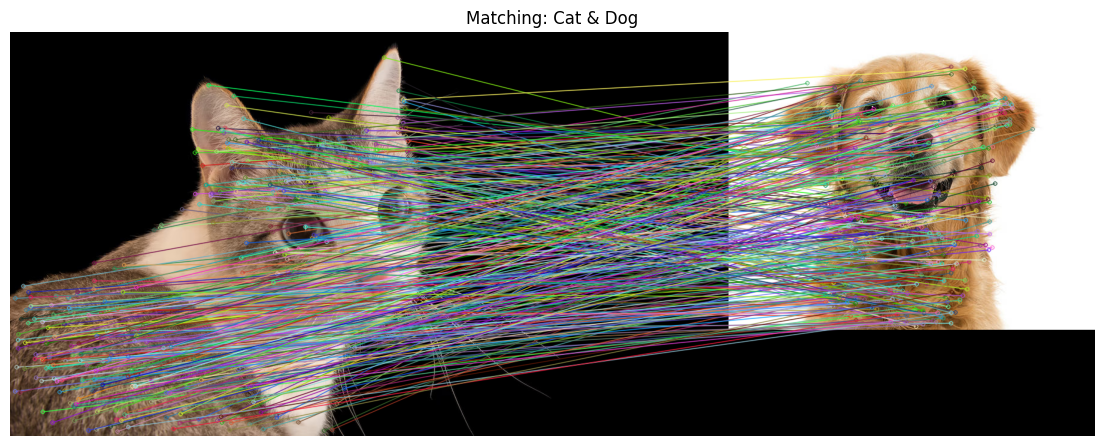

Number of Keypoints Detected in Cat Image: 2478
Number of Keypoints Detected in Dog Image: 889
Number of Matching Keypoints Found: 373


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_cat = cv2.imread('./c3.jpg')
training_image = cv2.cvtColor(image_cat, cv2.COLOR_BGR2RGB)
training_gray = cv2.cvtColor(training_image, cv2.COLOR_RGB2GRAY)

image_dog = cv2.imread('./doggo.jpg')
testing_image = cv2.cvtColor(image_dog, cv2.COLOR_BGR2RGB)
testing_gray = cv2.cvtColor(testing_image, cv2.COLOR_RGB2GRAY)

sift = cv2.SIFT_create()
cat_keypoints, cat_descriptor = sift.detectAndCompute(training_gray, None)
dog_keypoints, dog_descriptor = sift.detectAndCompute(testing_gray, None)

bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck=True)
matches = bf.match(cat_descriptor, dog_descriptor)
matches = sorted(matches, key = lambda x : x.distance)
result = cv2.drawMatches(training_image, cat_keypoints, testing_image, dog_keypoints, matches, testing_gray, flags=2)

plt.figure(figsize=(14, 7))
plt.title('Matching: Cat & Dog')
plt.imshow(result)
plt.axis('off')
plt.show()

print(f"Number of Keypoints Detected in Cat Image: {len(cat_keypoints)}")
print(f"Number of Keypoints Detected in Dog Image: {len(dog_keypoints)}")
print(f"Number of Matching Keypoints Found: {len(matches)}")

SIFT detects kepoints and features such as corners and blobs. Then it makes a descriptor of keypoint which later on works as matching between the cat-cat and cat-dog images. It works even if the testing image is transformed and not in the original orientation. So, even if the cat shape shifts as a dog, SIFT can find it by feature extraction and matching.

task3


In [19]:
s1 = cv2.imread('./s3.jpg')
s2 = cv2.imread('./s5.jpg')
s3 = cv2.imread('./s6.jpg')
s4 = cv2.imread('./s7.jpg')
s5 = cv2.imread('./r4.jpg')

road_list = [s1, s2, s3, s5]

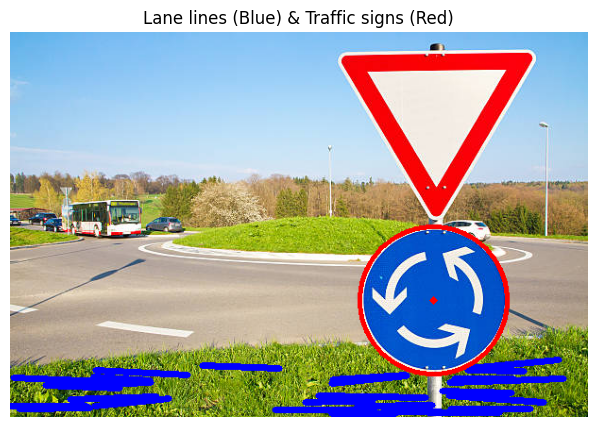

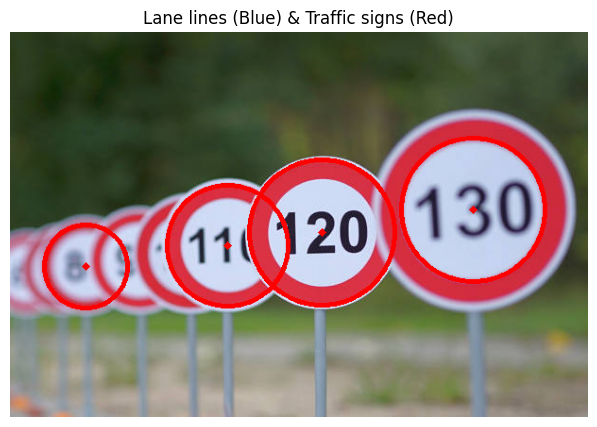

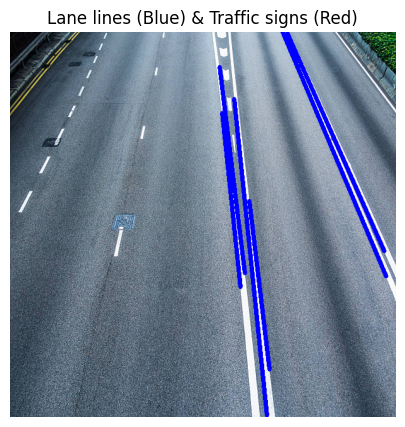

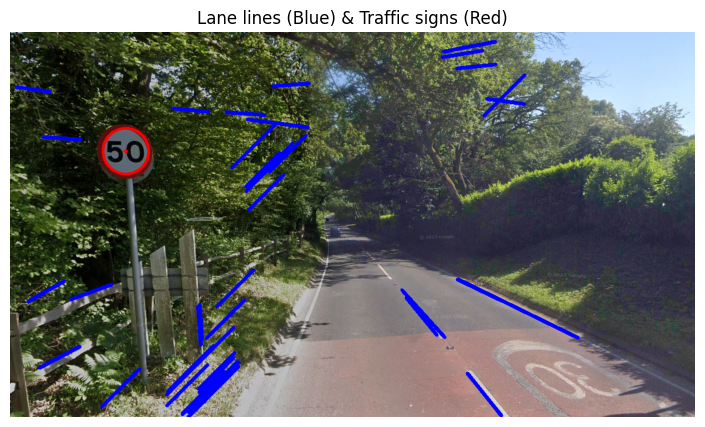

In [20]:
for i in road_list:
  road = i
  road_rgb = cv2.cvtColor(road, cv2.COLOR_BGR2RGB)
  road_gray = cv2.cvtColor(road_rgb, cv2.COLOR_RGB2GRAY)

  output_image = np.copy(road_rgb)
  blur_gray_for_lines = cv2.GaussianBlur(road_gray, (5, 5), sigmaX=0)

  low_threshold = 50
  high_threshold = 150
  edges = cv2.Canny(blur_gray_for_lines, low_threshold, high_threshold)

  # lines
  rho = 1
  theta = np.pi/180
  threshold = 200
  min_line_length = 60
  max_line_gap = 5

  lines = cv2.HoughLinesP(edges, rho, theta, threshold, np.array([]), min_line_length, max_line_gap)

  if lines is not None:
      for line in lines:
          for x1,y1,x2,y2 in line:
              cv2.line(output_image,(x1,y1),(x2,y2),(0,0,255),5)
  blur_gray_for_circles = cv2.medianBlur(road_gray, 5)


  # circle
  circles = cv2.HoughCircles(blur_gray_for_circles, cv2.HOUGH_GRADIENT, 1, 100, param1=150, param2=45, minRadius=20, maxRadius=80)

  if circles is not None:
      detected_circles = np.uint16(np.around(circles))
      for (x, y ,r) in detected_circles[0, :]:
          cv2.circle(output_image, (x, y), r, (255, 0, 0), 3)
          cv2.circle(output_image, (x, y), 2, (255, 0, 0), 3)

  plt.figure(figsize=(10, 5))
  plt.imshow(output_image)
  plt.title('Lane lines (Blue) & Traffic signs (Red)')
  plt.axis('off')
  plt.show()